In [1]:
from dotenv import load_dotenv

load_dotenv()

True

# Basic Chatbot

In [2]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list, add_messages] # add_messages is a reducer which appends messages to list "messages"

In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", temperature=0)
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x11dcc30e0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x11ddf8440>, model_name='llama-3.1-8b-instant', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
def chatbot(state: State) -> State:
    return {"messages":[llm.invoke(state["messages"])]}

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(State)

workflow.add_node("chatbot", chatbot)

workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot", END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png())) 

In [ ]:
response = graph.invoke({"messages":"Hi"})
response["messages"][-1].content  # Get the last message from the response

In [ ]:
for event in graph.stream({"messages":"Hi"}):
    for value in event.values():
        print(value["messages"][-1].content)  # Print the last message from each event

# Chatbot with tools

In [3]:
from langchain_tavily import TavilySearch

output = []
tool = TavilySearch(search_depth="advanced")
response = tool.invoke("What is toothless?")
for result in response["results"]:
    output.append(result["content"])

output

['**Toothless** is [Hiccup Horrendous Haddock III\'s](https://howtotrainyourdragon.fandom.com/wiki/Hiccup_Horrendous_Haddock_III_(Franchise) "Hiccup Horrendous Haddock III (Franchise)") [Night Fury](https://howtotrainyourdragon.fandom.com/wiki/Night_Fury_(Franchise) "Night Fury (Franchise)") and the main dragon character of the [_How to Train Your Dragon_ franchise](https://howtotrainyourdragon.fandom.com/wiki/DreamWorks_Dragons_(Franchise) "DreamWorks Dragons (Franchise)"). By the end of the [...] Toothless is the most intelligent of all known dragons, and seems to have a dry sense of humor, similar to that of Hiccup. When Hiccup released him, he did not kill Hiccup, as it is possible that he sensed goodness in the boy, or that he was simply repaying the favour by leaving him alive. He was still very wary and would not let Hiccup near him for several days. [...] **Swimming:** Toothless is a great swimmer and has saved Hiccup from drowning several times in the process. He can both trea

In [56]:
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers.
    Args:
        a (int): The first integer.
        b (int): The second integer.
    Returns:
        int: The product of the two integers.
    """
    return a * b

In [6]:
#tools = [tool, multiply]
tools = [tool]
llm_with_tools = llm.bind_tools(tools)

In [7]:
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# ReAct Agent Architecture

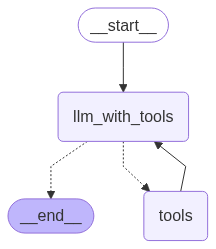

In [8]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

workflow = StateGraph(State)

workflow.add_node("llm_with_tools", tool_calling_llm)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "llm_with_tools")
workflow.add_conditional_edges(
    "llm_with_tools",
    # if latest message is a tool call then routes to tools
    # else routes to END
    tools_condition
)
workflow.add_edge("tools", "llm_with_tools")
workflow.add_edge("llm_with_tools", END)

graph = workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [9]:
response = graph.invoke({"messages":"What is toothless?"})
response["messages"][-1].content 
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is toothless?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (qfte6zj1m)
 Call ID: qfte6zj1m
  Args:
    query: toothless
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "toothless", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://howtotrainyourdragon.fandom.com/wiki/Toothless_(Franchise)", "title": "Toothless | How to Train Your Dragon Wiki - Fandom", "content": "**Toothless** is [Hiccup Horrendous Haddock III's](https://howtotrainyourdragon.fandom.com/wiki/Hiccup_Horrendous_Haddock_III_(Franchise) \"Hiccup Horrendous Haddock III (Franchise)\") [Night Fury](https://howtotrainyourdragon.fandom.com/wiki/Night_Fury_(Franchise) \"Night Fury (Franchise)\") and the main dragon character of the [_How to Train Your Dragon_ fr

# Adding Memory

In [10]:
response = graph.invoke({"messages":"Hello I'm Siddu"})
response["messages"][-1].content 

"Hello Siddu, it's nice to meet you. Is there anything I can help you with today?"

In [11]:
response = graph.invoke({"messages":"what's my name?"})
response["messages"][-1].content 

"I don't have any information about your name. I'm a large language model, I don't have the ability to know or remember personal information about individual users. Each time you interact with me, it's a new conversation and I don't retain any information from previous conversations. If you'd like to share your name with me, I can try to remember it for the duration of our conversation."

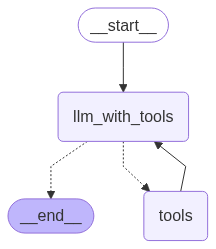

In [12]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display

memory = MemorySaver()

workflow = StateGraph(State)

workflow.add_node("llm_with_tools", tool_calling_llm)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "llm_with_tools")
workflow.add_conditional_edges(
    "llm_with_tools",
    # if latest message is a tool call then routes to tools
    # else routes to END
    tools_condition
)
workflow.add_edge("tools", "llm_with_tools")
workflow.add_edge("llm_with_tools", END)

graph = workflow.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [13]:
config={"configurable":{"thread_id":"5"}}

In [14]:
response = graph.invoke({"messages":"Hello I'm Siddu"},config=config)
response["messages"][-1].content 

"Hello Siddu, it's nice to meet you. Is there anything I can help you with today?"

In [15]:
response = graph.invoke({"messages":"What's my name?"},config=config)
response["messages"][-1].content 

'Your name is Siddu.'

# Streaming

In [118]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [119]:
def superbot(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [ ]:
workflow = StateGraph(State)

workflow.add_node("superbot", superbot)

workflow.add_edge(START, "superbot")
workflow.add_edge("superbot", END)

graph = workflow.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config={"configurable":{"thread_id":"2"}}
graph.invoke({"messages":"Hello I'm Sid. Nice to meet you"},config=config)

In [ ]:
config={"configurable":{"thread_id":"3"}}

for chunk in graph.stream({"messages":"Hello I'm Sid. Nice to meet you"}, config, stream_mode="updates"):
    print(chunk)

In [ ]:
for chunk in graph.stream({"messages":"Hello I'm Sid. Nice to meet you"}, config, stream_mode="values"):
    print(chunk)